# Comprobar valores — R simulada vs. R experimental en la franja `V=[0.9, 1.1] V`

Objetivo puntual: comparar la resistencia de la simulación `evitar_escalon_4/simulation_1`
(`grosor=[1,2]`, `sigma_0=4.5e8`) contra la resistencia experimental (`Cycle_p_1000.txt`),
**en el mismo tramo de tensión** (`0.9–1.1 V`, donde ambas curvas deberían seguir la ley
de Ohm), en vez de comparar el final caliente de `PP_set` contra `R_objetivo` (que es un
valor **frío**, medido en `V≤0.25V` de la rama de bajada — no es la misma magnitud, ver
conversación).

Mismo método de ajuste que en `Fase0_Calibracion_sigma0.ipynb`: lineal forzado por el
origen (`G = sum(V*I)/sum(V**2)`, `R = 1/G`), no una regresión con término independiente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ruta_raiz = Path.cwd()

V_MIN, V_MAX = 0.9, 1.1

RUTA_SIM = ruta_raiz / "evitar_escalon_4" / "simulation_1" / "Data_pp_set_1.npz"
RUTA_EXP = ruta_raiz / "Datos_Experimentales" / "Ciclos_Experimentales" / "Cycle_p_1000.txt"

In [2]:
def ajuste_por_origen(V, I, mask=None):
    """Ajuste lineal I = G*V forzado por el origen. Devuelve (R, R2, n_puntos).

    Mismo metodo que Fase0_Calibracion_sigma0.ipynb: G = sum(V*I)/sum(V**2) -> R=1/G.
    """
    if mask is not None:
        V, I = V[mask], I[mask]
    if len(V) == 0:
        raise ValueError("Ventana vacia: ningun punto cumple la condicion de V.")
    G = np.sum(V * I) / np.sum(V**2)
    R = 1.0 / G
    I_pred = G * V
    ss_res = np.sum((I - I_pred) ** 2)
    ss_tot = np.sum((I - np.mean(I)) ** 2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return R, R2, len(V)

In [3]:
def ajuste_local(V, I, mask=None):
    """Regresion lineal ESTANDAR (con termino independiente): I = G*V + b.

    Forzar por el origen (ajuste_por_origen) solo tiene sentido fisico cuando la
    ventana incluye V=0 (I(0)=0 es una restriccion real). Aqui la ventana esta lejos
    del origen (0.9-1.1V) -- no hay motivo para imponer que la recta pase por (0,0), y
    hacerlo sesga la pendiente local (se ve en el grafico: la recta forzada queda por
    encima de los datos al principio de la ventana y por debajo al final). Esta
    version deja que el ajuste encuentre su propio intercepto -> representa la
    pendiente local real (resistencia diferencial), no una extrapolacion desde el
    origen.

    Devuelve (R, R2, intercepto, n_puntos).
    """
    if mask is not None:
        V, I = V[mask], I[mask]
    if len(V) == 0:
        raise ValueError("Ventana vacia: ningun punto cumple la condicion de V.")
    A = np.vstack([V, np.ones_like(V)]).T
    G, b = np.linalg.lstsq(A, I, rcond=None)[0]
    R = 1.0 / G
    I_pred = G * V + b
    ss_res = np.sum((I - I_pred) ** 2)
    ss_tot = np.sum((I - np.mean(I)) ** 2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return R, R2, b, len(V)

## 1. Resistencia de la simulación (`Data_pp_set_1.npz`, columnas `[t, V, I_total, R_total, ...]`)

In [4]:
datos_sim = np.load(RUTA_SIM)["datos_sim"]
V_sim, I_sim = datos_sim[:, 1], datos_sim[:, 2]

mask_sim = (V_sim >= V_MIN) & (V_sim <= V_MAX)
R_sim, R2_sim, n_sim = ajuste_por_origen(V_sim, I_sim, mask_sim)

print(f"Simulacion: {n_sim} puntos en V=[{V_MIN},{V_MAX}]")
print(f"R_sim = {R_sim:.4f} Ohm   (R2={R2_sim:.5f})")

Simulacion: 1817 puntos en V=[0.9,1.1]
R_sim = 50.9343 Ohm   (R2=0.91529)


## 2. Resistencia experimental (`Cycle_p_1000.txt`, rama de subida — la que corresponde
físicamente a `PP_set`, ver `CLAUDE.md`/plan: `pp_set` equivale a `0.01 -> 1.1V`)

In [5]:
datos_exp = np.loadtxt(RUTA_EXP)  # sin skiprows: el fichero no tiene cabecera
V_exp_full, I_exp_full = datos_exp[:, 0], datos_exp[:, 1]

idx_max = int(np.argmax(V_exp_full))
V_subida, I_subida = V_exp_full[: idx_max + 1], I_exp_full[: idx_max + 1]

mask_exp = (V_subida >= V_MIN) & (V_subida <= V_MAX)
R_exp, R2_exp, n_exp = ajuste_por_origen(V_subida, np.abs(I_subida), mask_exp)

print(f"Experimental (rama de subida): {n_exp} puntos en V=[{V_MIN},{V_MAX}]")
print(f"R_exp = {R_exp:.4f} Ohm   (R2={R2_exp:.5f})")

Experimental (rama de subida): 21 puntos en V=[0.9,1.1]
R_exp = 45.7297 Ohm   (R2=0.80575)


## 3. Comparación

                              forzado por origen  local (con intercepto)
R_sim                                 50.9343 Ω              65.7124 Ω
R2_sim                                   0.91529                 0.99973
R_exp                                 45.7297 Ω              25.7624 Ω
R2_exp                                   0.80575                 0.99642
diferencia sim vs exp                     11.38%                 155.07%


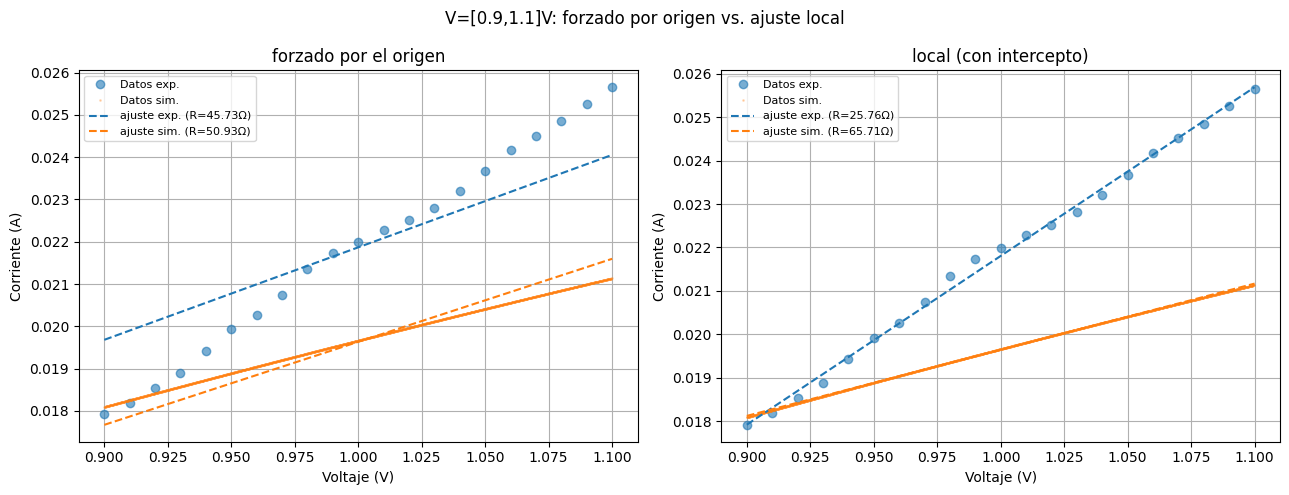

In [6]:
R_sim_local, R2_sim_local, b_sim, _ = ajuste_local(V_sim, I_sim, mask_sim)
R_exp_local, R2_exp_local, b_exp, _ = ajuste_local(V_subida, np.abs(I_subida), mask_exp)

diff_pct = 100 * (R_sim - R_exp) / R_exp
diff_pct_local = 100 * (R_sim_local - R_exp_local) / R_exp_local

print("=" * 60)
print(f"{'':<28}{'forzado por origen':>20}{'local (con intercepto)':>24}")
print(f"{'R_sim':<28}{R_sim:>17.4f} Ω{R_sim_local:>21.4f} Ω")
print(f"{'R2_sim':<28}{R2_sim:>20.5f}{R2_sim_local:>24.5f}")
print(f"{'R_exp':<28}{R_exp:>17.4f} Ω{R_exp_local:>21.4f} Ω")
print(f"{'R2_exp':<28}{R2_exp:>20.5f}{R2_exp_local:>24.5f}")
print(f"{'diferencia sim vs exp':<28}{diff_pct:>19.2f}%{diff_pct_local:>23.2f}%")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, titulo in [(ax1, "forzado por el origen"), (ax2, "local (con intercepto)")]:
    ax.plot(V_subida[mask_exp], np.abs(I_subida[mask_exp]), "o", alpha=0.6, label="Datos exp.")
    ax.plot(V_sim[mask_sim], I_sim[mask_sim], ".", alpha=0.25, markersize=2, label="Datos sim.")
    V_line = np.linspace(V_MIN, V_MAX, 20)
    if titulo == "forzado por el origen":
        ax.plot(V_line, V_line / R_exp, "--", color="tab:blue", label=f"ajuste exp. (R={R_exp:.2f}Ω)")
        ax.plot(V_line, V_line / R_sim, "--", color="tab:orange", label=f"ajuste sim. (R={R_sim:.2f}Ω)")
    else:
        ax.plot(V_line, V_line / R_exp_local + b_exp, "--", color="tab:blue", label=f"ajuste exp. (R={R_exp_local:.2f}Ω)")
        ax.plot(V_line, V_line / R_sim_local + b_sim, "--", color="tab:orange", label=f"ajuste sim. (R={R_sim_local:.2f}Ω)")
    ax.set_xlabel("Voltaje (V)")
    ax.set_ylabel("Corriente (A)")
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(f"V=[{V_MIN},{V_MAX}]V: forzado por origen vs. ajuste local")
plt.tight_layout()
plt.show()

## 4. Ajuste sobre TODA la rama de bajada (SP_set) — solo datos experimentales

`Cycle_p_1000.txt` no tiene cabecera: 220 filas, `[V,I,?]`. Rama de subida = `PP_set`
(`0.01→1.1V`), rama de bajada = `SP_set` (`1.1→0V`) — ver `CLAUDE.md`. Aquí se ajusta
**toda** la rama de bajada de una vez (no solo la ventana fría `V≤0.25V` que usa
`R_objetivo`, ni la ventana caliente `V=[0.9,1.1]` de arriba): forzado por el origen
tiene sentido físico en este caso porque el rango sí incluye `V→0`.

Rama de bajada (SP_set) completa: 111 puntos, V de 1.1000 a -0.0000 V
R_SP_set (toda la rama, forzado por el origen) = 41.8468 Ohm   (R2=0.99972)

Comparacion con las ventanas ya calculadas:
  R_objetivo (solo V<=0.25V, punto frio)       : 41.14 Ohm   (referencia del plan)
  R_SP_set (rama completa 0-1.1V)               : 41.8468 Ohm
  R_exp en V=[0.9,1.1] (solo la ventana caliente): 45.7297 Ohm


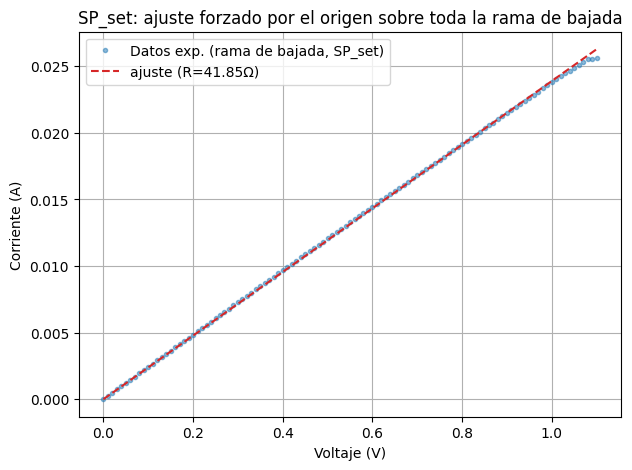

In [7]:
V_bajada_full = V_exp_full[idx_max:]
I_bajada_full = I_exp_full[idx_max:]

R_sp_set, R2_sp_set, n_sp_set = ajuste_por_origen(V_bajada_full, np.abs(I_bajada_full))

print(f"Rama de bajada (SP_set) completa: {n_sp_set} puntos, V de {V_bajada_full[0]:.4f} a {V_bajada_full[-1]:.4f} V")
print(f"R_SP_set (toda la rama, forzado por el origen) = {R_sp_set:.4f} Ohm   (R2={R2_sp_set:.5f})")
print()
print(f"Comparacion con las ventanas ya calculadas:")
print(f"  R_objetivo (solo V<=0.25V, punto frio)       : 41.14 Ohm   (referencia del plan)")
print(f"  R_SP_set (rama completa 0-1.1V)               : {R_sp_set:.4f} Ohm")
print(f"  R_exp en V=[0.9,1.1] (solo la ventana caliente): {R_exp:.4f} Ohm")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(V_bajada_full, np.abs(I_bajada_full), "o", markersize=3, alpha=0.5, label="Datos exp. (rama de bajada, SP_set)")
V_line_full = np.linspace(0, V_bajada_full.max(), 50)
ax.plot(V_line_full, V_line_full / R_sp_set, "--", color="tab:red", label=f"ajuste (R={R_sp_set:.2f}Ω)")
ax.set_xlabel("Voltaje (V)")
ax.set_ylabel("Corriente (A)")
ax.set_title("SP_set: ajuste forzado por el origen sobre toda la rama de bajada")
ax.legend()
ax.grid(True)
plt.show()